In [ ]:
Supply_Chain_Demand_Forecasting_Prophet

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score
from prophet.plot import plot_plotly, plot_components_plotly
import warnings
warnings.filterwarnings('ignore')
import numpy as np

In [3]:
from google.colab import files
import pandas as pd
uploaded = files.upload()


Saving sales_data_clean.csv to sales_data_clean.csv


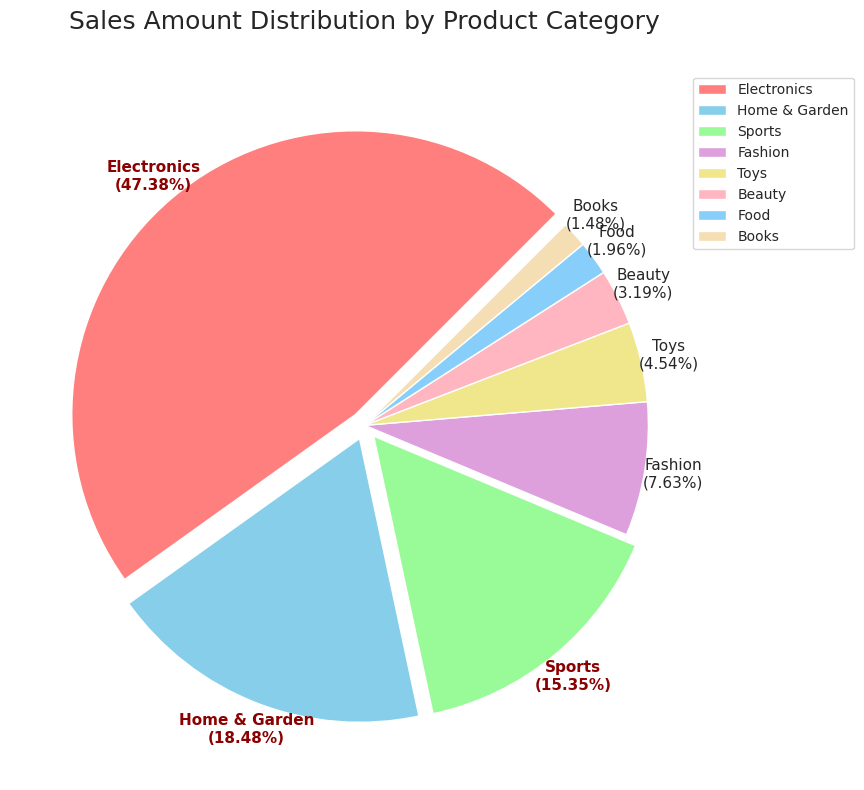

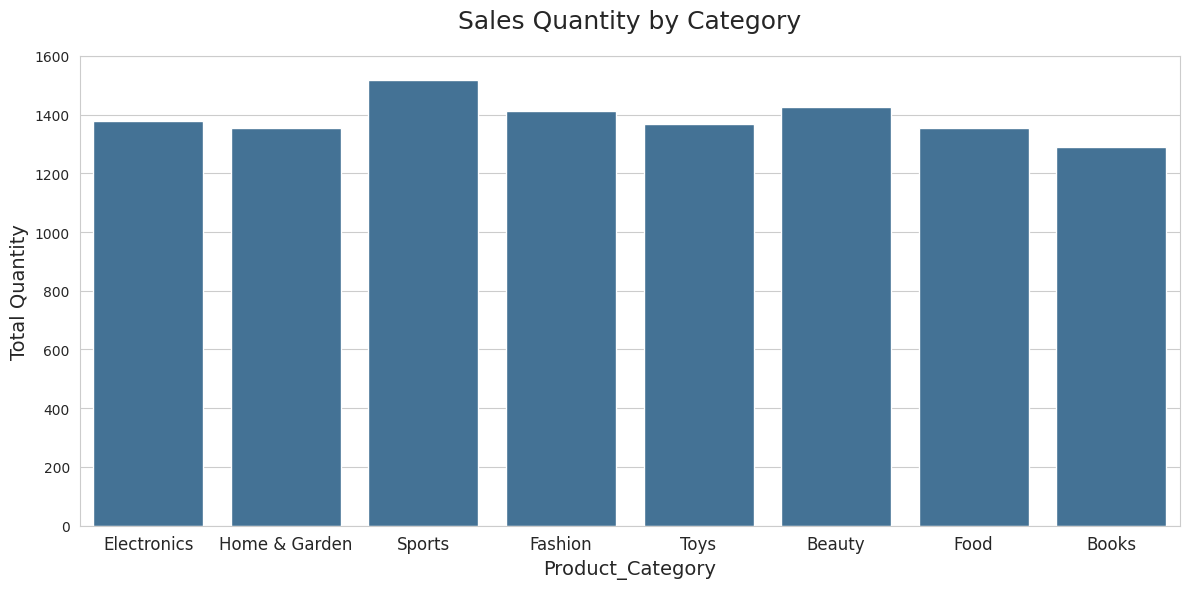

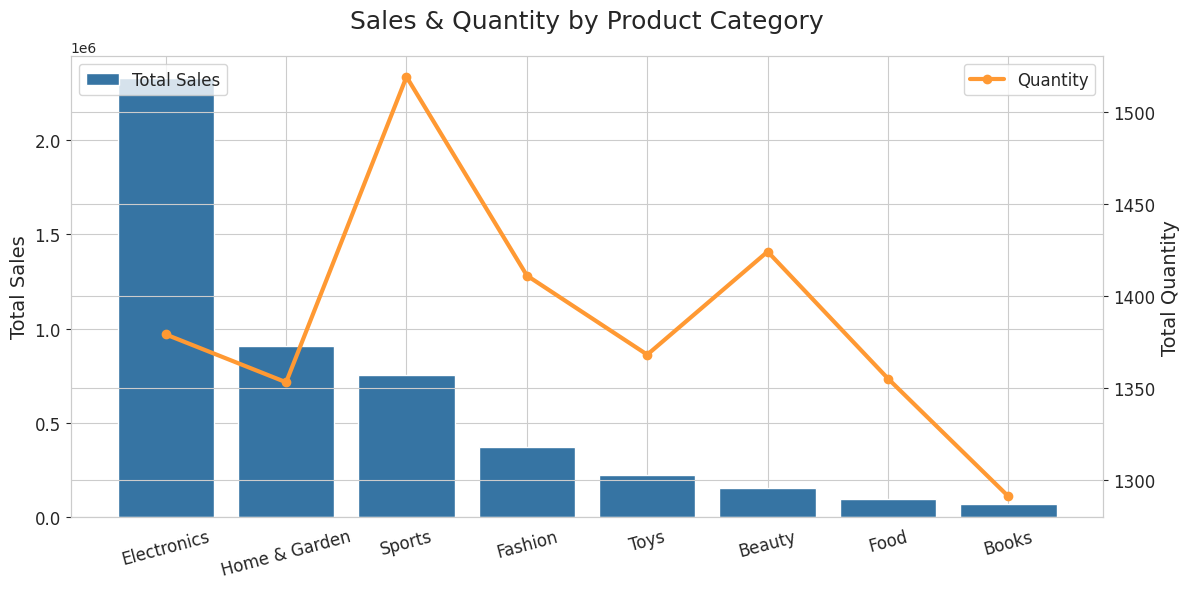

Processing Electronics Category...
Processing Home & Garden Category...
Processing Sports Category...
Processing Fashion Category...
Processing Toys Category...
Processing Beauty Category...
Processing Food Category...
Processing Books Category...
Prophet Model Performance Evaluation - Electronics Category
RMSE: 2.84
R²: 0.08
Prophet Model Performance Evaluation - Home & Garden Category
RMSE: 2.9
R²: 0.08
Prophet Model Performance Evaluation - Sports Category
RMSE: 3.05
R²: 0.08
Prophet Model Performance Evaluation - Fashion Category
RMSE: 2.67
R²: 0.1
Prophet Model Performance Evaluation - Toys Category
RMSE: 3.02
R²: 0.08
Prophet Model Performance Evaluation - Beauty Category
RMSE: 2.71
R²: 0.07
Prophet Model Performance Evaluation - Food Category
RMSE: 2.8
R²: 0.1
Prophet Model Performance Evaluation - Books Category
RMSE: 2.68
R²: 0.14


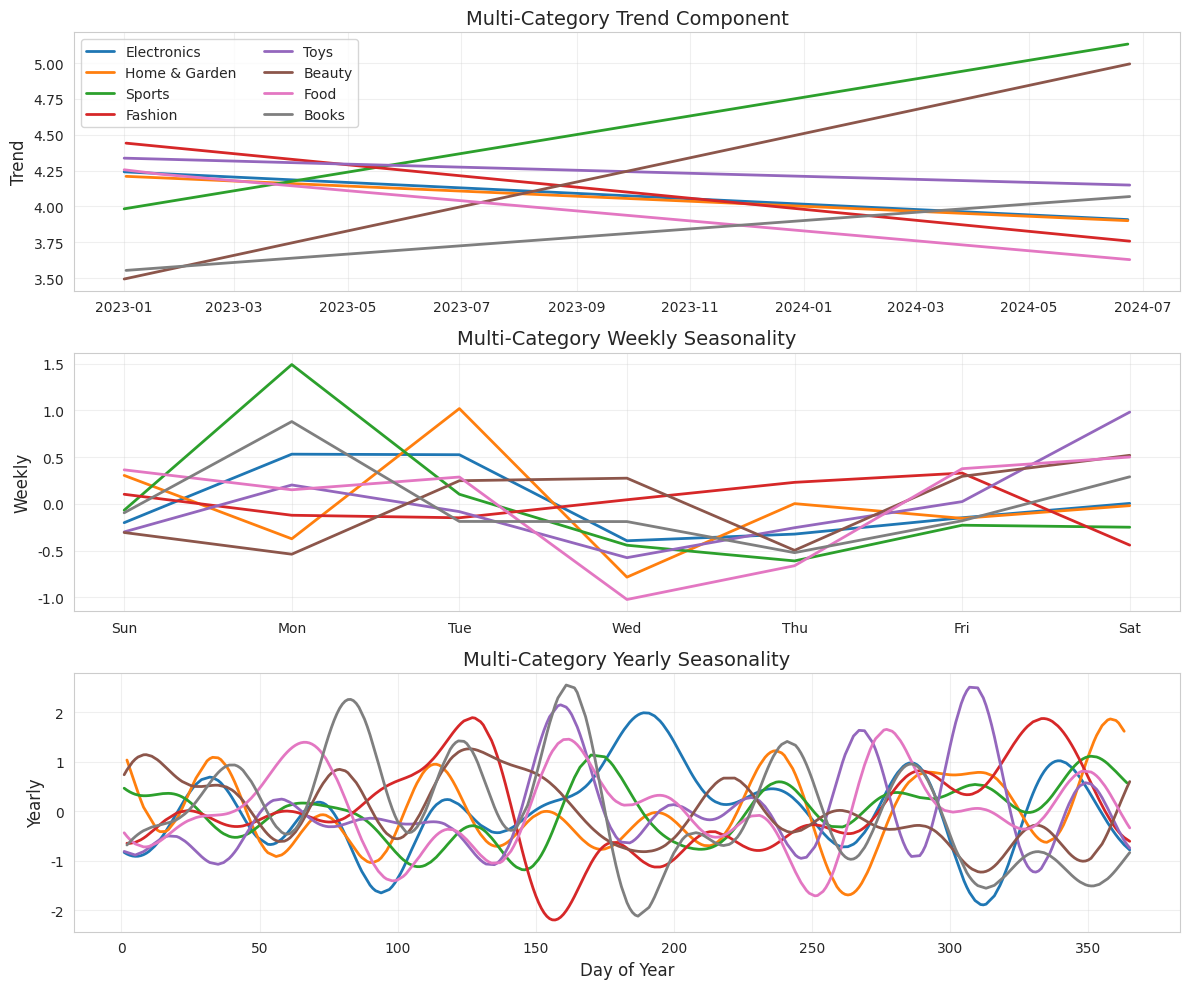

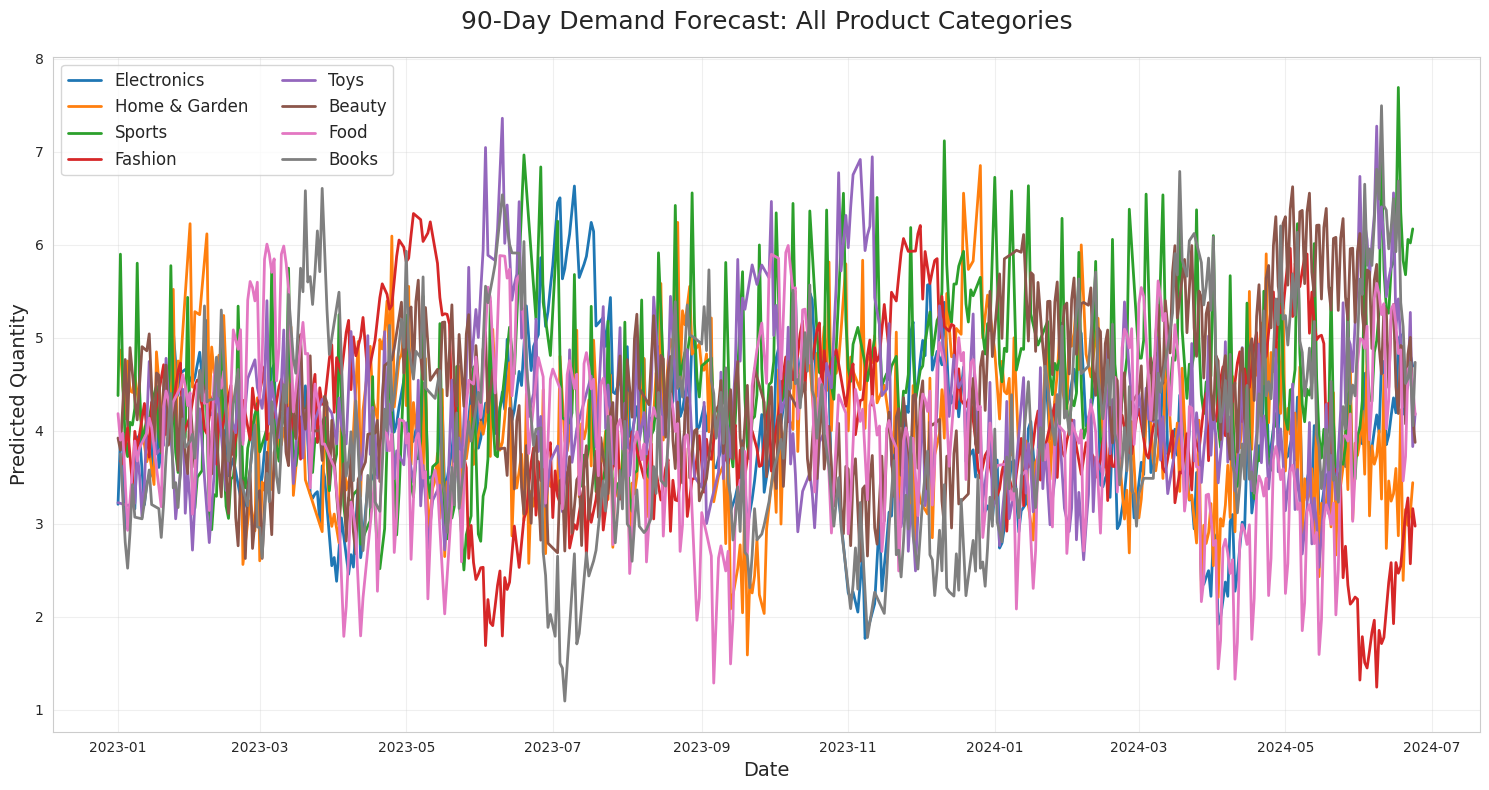

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All CSV files downloaded successfully (Colab Environment)


In [11]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 2. Set Visualization Style
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# 3. Load and Preprocess Data
df = pd.read_csv('sales_data_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])

# 4. Basic Data Aggregation
category_analysis = df.groupby('Product_Category').agg({
    'Quantity': 'sum',
    'Total_Amount': 'sum'
}).sort_values(by='Total_Amount', ascending=False)

category_analysis['AOV'] = category_analysis['Total_Amount'] / category_analysis['Quantity']
category_analysis['Sales_Percent'] = (category_analysis['Total_Amount'] / category_analysis['Total_Amount'].sum()) * 100

# ==============================================
# Part 1: Descriptive Analytics - Core Charts
# ==============================================

# ---------- Chart 1: Sales Amount Distribution Pie Chart ----------
plt.figure(figsize=(12, 8))
colors = ['#FF7F7F', '#87CEEB', '#98FB98', '#DDA0DD', '#F0E68C', '#FFB6C1', '#87CEFA', '#F5DEB3']
sales_percent = category_analysis['Sales_Percent'].round(2)
labels = [f'{cat}\n({pct}%)' for cat, pct in zip(category_analysis.index, sales_percent)]
explode = [0.05 if p > 10 else 0 for p in sales_percent]

patches, texts, autotexts = plt.pie(
    sales_percent,
    labels=labels,
    autopct='',
    explode=explode,
    colors=colors,
    startangle=45,
    textprops={'fontsize': 11, 'ha': 'center'},
    labeldistance=1.1
)

for i, text in enumerate(texts):
    if sales_percent.iloc[i] > 10:
        text.set_fontweight('bold')
        text.set_color('darkred')

plt.title('Sales Amount Distribution by Product Category', fontsize=18, pad=30)
plt.tight_layout()
plt.legend(patches, category_analysis.index, loc='upper right', bbox_to_anchor=(1.2, 1))
plt.savefig('sales_amount_distribution_pie.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------- Chart 2: Sales Quantity by Category ----------
plt.figure(figsize=(12, 6))
category_order = ['Electronics', 'Home & Garden', 'Sports', 'Fashion', 'Toys', 'Beauty', 'Food', 'Books']
quantity_values = [category_analysis.loc[cat, 'Quantity'] for cat in category_order]

ax2 = sns.barplot(x=category_order, y=quantity_values, color='#3674A3')
plt.title('Sales Quantity by Category', fontsize=18, pad=20)
plt.ylabel('Total Quantity', fontsize=14)
plt.xlabel('Product_Category', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.ylim(0, 1600)
plt.tight_layout()
plt.savefig('sales_quantity_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------- Chart 3: Sales & Quantity Dual-Axis Chart ----------
category_sum = df.groupby('Product_Category').agg(
    Total_Amount=('Total_Amount', 'sum'),
    Quantity=('Quantity', 'sum')
).reset_index()
category_sum = category_sum.set_index('Product_Category').loc[category_order].reset_index()

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.bar(category_sum['Product_Category'], category_sum['Total_Amount'], color='#3674A3', label='Total Sales')
ax1.set_ylabel('Total Sales', fontsize=14)
ax1.tick_params(axis='x', rotation=15, labelsize=12)
ax1.tick_params(axis='y', labelsize=12)

ax2 = ax1.twinx()
ax2.plot(category_sum['Product_Category'], category_sum['Quantity'], color='#FF9933', marker='o', linewidth=3, label='Quantity')
ax2.set_ylabel('Total Quantity', fontsize=14)
ax2.tick_params(axis='y', labelsize=12)

plt.title('Sales & Quantity by Product Category', fontsize=18, pad=20)
ax1.legend(loc='upper left', fontsize=12)
ax2.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.savefig('sales_quantity_dual_axis.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================
# Part 2: Full Category Prophet Forecasting
# ==============================================
# Fixed category order (consistent with charts)
category_order = ['Electronics', 'Home & Garden', 'Sports', 'Fashion', 'Toys', 'Beauty', 'Food', 'Books']

# Store forecasts and evaluation results
forecast_dict = {}
eval_results = {}

for cat in category_order:
    print(f"Processing {cat} Category...")
    # Filter and aggregate data for current category
    cat_data = df[df['Product_Category'] == cat].copy()
    cat_ts = cat_data.groupby('Date')['Quantity'].sum().reset_index()
    cat_ts.columns = ['ds', 'y']  # Rename to Prophet's required format

    # Initialize and train Prophet model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )
    model.fit(cat_ts)

    # Generate 90-day forecast
    future = model.make_future_dataframe(periods=90)
    forecast = model.predict(future)

    # Calculate model performance metrics (on historical data only)
    y_true = cat_ts['y'].values
    y_pred = forecast.iloc[:len(y_true)]['yhat'].values
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Save results
    forecast_dict[cat] = forecast
    eval_results[cat] = {'RMSE': round(rmse, 2), 'R²': round(r2, 2)}

    # Save individual category forecast to CSV
    forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    forecast_output.to_csv(f'{cat}_90day_forecast.csv', index=False)

# ==============================================
# Print Model Performance Evaluation (per category)
# ==============================================
for cat in category_order:
    print("="*60)
    print(f"Prophet Model Performance Evaluation - {cat} Category")
    print("="*60)
    print(f"RMSE: {eval_results[cat]['RMSE']}")
    print(f"R²: {eval_results[cat]['R²']}")
    print("="*60)

# ==============================================
# Chart 4: Multi-Category Seasonal Components (Trend + Weekly + Yearly)
# ==============================================
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
colors = sns.color_palette("tab10", n_colors=8)

# Subplot 1: Trend Component
for i, cat in enumerate(category_order):
    fc = forecast_dict[cat]
    ax1.plot(fc['ds'], fc['trend'], label=cat, color=colors[i], linewidth=2)
ax1.set_title('Multi-Category Trend Component', fontsize=14)
ax1.set_ylabel('Trend', fontsize=12)
ax1.legend(ncol=2, fontsize=10)
ax1.grid(alpha=0.3)

# Subplot 2: Weekly Seasonality Component
# Prophet's weekly component is fixed. We need to derive day_of_week from 'ds' for plotting.
for i, cat in enumerate(category_order):
    fc = forecast_dict[cat].copy() # Use a copy to avoid SettingWithCopyWarning if modifying in place
    # Calculate day of week, adjusting so Sunday is 0 to align with desired x-axis labels
    fc['day_of_week_plot'] = (fc['ds'].dt.dayofweek + 1) % 7 # Sunday=0, Monday=1, ..., Saturday=6

    # Extract unique weekly component for each day of the week and sort by day_of_week_plot
    weekly_component_data = fc[['day_of_week_plot', 'weekly']].drop_duplicates(subset=['day_of_week_plot']).sort_values('day_of_week_plot')

    ax2.plot(weekly_component_data['day_of_week_plot'], weekly_component_data['weekly'], label=cat, color=colors[i], linewidth=2)
ax2.set_xticks(range(7))
ax2.set_xticklabels(['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']) # These labels now correctly align with day_of_week_plot
ax2.set_title('Multi-Category Weekly Seasonality', fontsize=14)
ax2.set_ylabel('Weekly', fontsize=12)
ax2.grid(alpha=0.3)

# Subplot 3: Yearly Seasonality Component
for i, cat in enumerate(category_order):
    fc = forecast_dict[cat]
    yearly = fc[fc['ds'].dt.year == 2023][['yearly', 'ds']].copy()
    yearly['dayofyear'] = yearly['ds'].dt.dayofyear
    ax3.plot(yearly['dayofyear'], yearly['yearly'], label=cat, color=colors[i], linewidth=2)
ax3.set_title('Multi-Category Yearly Seasonality', fontsize=14)
ax3.set_ylabel('Yearly', fontsize=12)
ax3.set_xlabel('Day of Year', fontsize=12)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('multi_category_seasonal_components.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================
# Chart 5: Multi-Category 90-Day Demand Forecast
# ==============================================
plt.figure(figsize=(15, 8))
for i, cat in enumerate(category_order):
    fc = forecast_dict[cat]
    plt.plot(fc['ds'], fc['yhat'], label=cat, color=colors[i], linewidth=2)
    # Optional: Add confidence interval
    # plt.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'], color=colors[i], alpha=0.1)

plt.title('90-Day Demand Forecast: All Product Categories', fontsize=18, pad=20)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Predicted Quantity', fontsize=14)
plt.legend(ncol=2, fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('multi_category_90day_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================
# Export All Summary CSV Files + Download Function
# ==============================================
# 1. Save category analysis summary
category_analysis.to_csv('category_analysis_summary.csv', index=True)

# 2. Save model evaluation results
eval_df = pd.DataFrame(eval_results).T
eval_df.to_csv('prophet_model_evaluation.csv', index=True)

# 3. Download function (support both Colab and local environment)
try:
    # For Google Colab
    from google.colab import files
    # Download all CSV files
    files.download('category_analysis_summary.csv')
    files.download('prophet_model_evaluation.csv')
    # Download individual category forecast CSV
    for cat in category_order:
        files.download(f'{cat}_90day_forecast.csv')
    print("\n✅ All CSV files downloaded successfully (Colab Environment)")
except ImportError:
    # For local environment (files saved to current working directory)
    print("\n✅ All CSV files saved to your current working directory (Local Environment)")
    print("📂 Files list:")
    print("   - category_analysis_summary.csv (Basic category metrics)")
    print("   - prophet_model_evaluation.csv (RMSE/R² for all categories)")
    print("   - [Category Name]_90day_forecast.csv (Individual category forecast)")